# Notebook 01 — Preparación del Dataset de ML
## Sistema de Recomendación Híbrido — Tesis

---

### 🎯 Objetivo

Este notebook construye el dataset maestro de Machine Learning (`dataset_ml.csv`) a partir de cuatro tablas fuente en crudo. El resultado alimenta directamente los modelos de recomendación híbrida (filtrado colaborativo + basado en contenido + reglas de negocio) desarrollados en notebooks posteriores.

---

### 📂 Archivos fuente (`../data/raw/`)

| Archivo | Filas (aprox.) | Descripción | Clave primaria |
|---|---|---|---|
| `clientes.csv` | 800 | Maestro de clientes HORECA: rubro, subrubro, sede | `cliente_id` |
| `productos.csv` | 1 799 | Catálogo de productos **por sede**: precio, stock, caducidad | `(producto_id, sede)` |
| `ventas.csv` | 7 950 | Cabecera de cada venta: fecha, cliente, monto total | `venta_id` |
| `detalle_venta.csv` | 36 003 | Líneas de venta: producto, cantidad, subtotal | `(venta_id, producto_id)` |

> **Nota importante sobre `productos.csv`:** Una misma referencia de producto (`producto_id`) puede aparecer en **varias filas**, una por cada sede (Lima, Cusco, Arequipa, Piura). Stock y días en stock varían por sede. Este diseño es la raíz del bug corregido en este notebook.

---

### 📋 Columnas del dataset de salida (28 columnas)

| # | Columna | Tipo | Fuente | Propósito en ML |
|---|---|---|---|---|
| 1 | `venta_id` | str | ventas | Identificador de transacción |
| 2 | `cliente_id` | str | ventas/clientes | Identificador de usuario |
| 3 | `producto_id` | str | detalle_venta | Identificador de ítem |
| 4 | `rubro_cliente` | str | clientes | Segmentación de cliente (nivel 1) |
| 5 | `subrubro_1` | str | clientes | Especialidad principal del negocio |
| 6 | `subrubro_2` | str | clientes | Formato de servicio (Delivery, Salón…) |
| 7 | `sede_cliente` | str | clientes | Sede geográfica del cliente |
| 8 | `categoria_producto` | str | productos | Familia de producto (Bebidas, Carnes…) |
| 9 | `precio_unitario` | float | productos | Precio de venta al cliente |
| 10 | `COSTO_UNITARIO` | float | productos | Costo de adquisición (margen bruto) |
| 11 | `stock` | int | productos | Unidades disponibles en la sede |
| 12 | `dias_en_stock` | int | productos | Días que lleva el lote en almacén |
| 13 | `sede` | str | productos | Sede de la que proviene el producto |
| 14 | `fecha_ingreso_catalogo` | date | productos | Antigüedad del producto en catálogo |
| 15 | `fecha_min_caducidad` | date | productos | Fecha de vencimiento más próxima |
| 16 | `dias_para_vencer` | int | calculado | Urgencia de venta (negativo = vencido) |
| 17 | `fecha_venta` | date | ventas | Fecha de la transacción |
| 18 | `monto_total` | float | ventas | Valor total del pedido |
| 19 | `cantidad_producto` | int | detalle_venta | Unidades compradas en esta línea |
| 20 | `subtotal` | float | detalle_venta | Monto de esta línea |
| 21 | `mes` | int | calculado | Estacionalidad mensual (1–12) |
| 22 | `semana_anio` | int | calculado | Estacionalidad semanal (1–53) |
| 23 | `es_feriado` | int (0/1) | calculado | Proximidad a feriado peruano (±3 días) |
| 24 | `frecuencia_compra` | float | calculado | Compras promedio por mes (histórico) |
| 25 | `ticket_promedio` | float | calculado | Monto promedio por venta del cliente |
| 26 | `descuento_aplicado` | float | calculado | Descuento real aplicado en la línea |
| 27 | `rotacion_diaria` | float | calculado | Velocidad de venta: unidades/día |
| 28 | `baja_rotacion` | int (0/1) | calculado | 1 si rotación ≤ percentil 25 |

---

### 🔗 Estrategia de join y corrección del bug de sede

**El problema:** `productos.csv` tiene **una fila por `(producto_id, sede)`**. Si hacemos `detalle.merge(productos, on='producto_id')` directamente, cada línea de venta se multiplica por el número de sedes donde existe ese producto (típicamente 2–4 veces), generando filas duplicadas y contaminando stock/días con datos de sedes incorrectas.

**La solución:** Primero resolvemos la sede del cliente (de `clientes.csv`), luego usamos esa sede como segunda clave del join con productos:

```
detalle_venta
    ↓ merge on venta_id
ventas  →  obtenemos cliente_id, fecha_venta
    ↓ merge on cliente_id
clientes  →  obtenemos sede_cliente
    ↓ merge on (producto_id, sede == sede_cliente)
productos  →  stock y días CORRECTOS para esa sede
```

Esto garantiza **exactamente una fila por línea de venta**, con los atributos de inventario correctos para la ubicación del cliente.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Project paths ────────────────────────────────────────────────────────────
# Este notebook vive en notebooks/ dentro de la raíz del proyecto.
# Path.cwd().parent sube un nivel hasta la raíz del proyecto.
ROOT_DIR = Path.cwd().parent   # notebooks/ is inside the project root
DATA_RAW = ROOT_DIR / "data" / "raw"
DATA_OUT = ROOT_DIR / "data" / "processed"
DATA_OUT.mkdir(parents=True, exist_ok=True)

print(f"Reading from: {DATA_RAW}")
print(f"Saving to:    {DATA_OUT}")
print(f"DATA_RAW exists: {DATA_RAW.exists()}")

Reading from: c:\Users\Camila\OneDrive - Universidad Peruana de Ciencias\repo_v2_tesis\data\raw
Saving to:    c:\Users\Camila\OneDrive - Universidad Peruana de Ciencias\repo_v2_tesis\data\processed
DATA_RAW exists: True


## 📂 Sección 1 — Carga de datos

Leemos los cuatro CSV con los tipos correctos desde el primer momento para evitar conversiones implícitas que puedan generar errores silenciosos en los joins.

### Relaciones entre tablas

```
clientes (800)          ventas (7 950)         detalle_venta (36 003)
  cliente_id ──────────── cliente_id               venta_id (FK)
  rubro_cliente            venta_id ──────────────── venta_id
  subrubro_1               fecha_venta              producto_id (FK)
  subrubro_2               monto_total              cantidad_producto
  sede_cliente                                      subtotal
                                                        │
productos (1 799)                                       ↓
  producto_id ◄──────────────────────────── producto_id
  sede          ← CLAVE COMPUESTA con sede_cliente
  categoria_producto
  precio_unitario
  COSTO_UNITARIO
  stock
  dias_en_stock
  fecha_ingreso_catalogo
  fecha_min_caducidad
```

**Cardinalidades:**
- `clientes` → `ventas`: 1 cliente puede tener muchas ventas (1:N)
- `ventas` → `detalle_venta`: 1 venta tiene muchas líneas (1:N)
- `productos` → `detalle_venta`: 1 producto aparece en muchas líneas (1:N), **pero con clave `(producto_id, sede)`**

In [14]:
# ── Carga de CSV con dtypes explícitos ───────────────────────────────────────
# clientes: todo como str para preservar IDs con ceros a la izquierda
clientes  = pd.read_csv(DATA_RAW / "clientes.csv",      dtype=str)
productos = pd.read_csv(DATA_RAW / "productos.csv")
ventas    = pd.read_csv(DATA_RAW / "ventas.csv")
detalle   = pd.read_csv(DATA_RAW / "detalle_venta.csv")

# ── Conversiones de tipo — productos ─────────────────────────────────────────
productos["precio_unitario"]        = productos["precio_unitario"].astype(float)
productos["COSTO_UNITARIO"]         = productos["COSTO_UNITARIO"].astype(float)
productos["stock"]                  = productos["stock"].astype(int)
productos["dias_en_stock"]          = productos["dias_en_stock"].astype(int)
productos["fecha_ingreso_catalogo"] = pd.to_datetime(productos["fecha_ingreso_catalogo"])
productos["fecha_min_caducidad"]    = pd.to_datetime(productos["fecha_min_caducidad"])
productos["producto_id"]            = productos["producto_id"].astype(str)

# ── Conversiones de tipo — ventas ─────────────────────────────────────────────
ventas["fecha_venta"] = pd.to_datetime(ventas["fecha_venta"])
ventas["monto_total"] = ventas["monto_total"].astype(float)
ventas["cliente_id"]  = ventas["cliente_id"].astype(str)
ventas["venta_id"]    = ventas["venta_id"].astype(str)

# ── Conversiones de tipo — detalle ───────────────────────────────────────────
detalle["cantidad_producto"] = detalle["cantidad_producto"].astype(int)
detalle["subtotal"]          = detalle["subtotal"].astype(float)
detalle["venta_id"]          = detalle["venta_id"].astype(str)
detalle["producto_id"]       = detalle["producto_id"].astype(str)

# ── Resumen de formas ─────────────────────────────────────────────────────────
print("Shapes:")
for name, df in [("clientes", clientes), ("productos", productos),
                 ("ventas", ventas), ("detalle", detalle)]:
    print(f"  {name:12s}: {df.shape}")

print("\nDTypes — productos:")
print(productos.dtypes)

Shapes:
  clientes    : (800, 5)
  productos   : (1814, 9)
  ventas      : (7950, 4)
  detalle     : (35735, 4)

DTypes — productos:
producto_id                       object
sede                              object
categoria_producto                object
precio_unitario                  float64
COSTO_UNITARIO                   float64
stock                              int32
dias_en_stock                      int32
fecha_ingreso_catalogo    datetime64[ns]
fecha_min_caducidad       datetime64[ns]
dtype: object


## 📊 Sección 2 — Análisis Exploratorio Inicial (EDA)

Antes de construir el dataset, exploramos cada tabla para entender su estructura, rangos de valores, y posibles problemas de calidad.

Puntos clave a verificar:
- **clientes:** ¿Cuántos rubros y sedes existen?
- **productos:** Confirmar que `producto_id` **no** es único (hay múltiples sedes por producto)
- **ventas:** Rango de fechas del dataset
- **detalle:** Distribución de cantidades y subtotales

In [15]:
# ── EDA: clientes ─────────────────────────────────────────────────────────────
# cliente_id: identificador único del cliente HORECA
# rubro_cliente: tipo de negocio (Restaurante, Bar, Bodega, Panadería, etc.)
# subrubro_1: especialidad dentro del rubro (Chifa, Pollería, 24 Horas, etc.)
# subrubro_2: formato de servicio (Salón, Delivery, Dark Kitchen, etc.)
# sede_cliente: ciudad donde opera el cliente (Lima, Cusco, Arequipa, Piura)
print("=" * 60)
print("CLIENTES")
print("=" * 60)
print(f"Clientes únicos: {clientes['cliente_id'].nunique()}")
print(f"Rubros: {sorted(clientes['rubro_cliente'].unique())}")
print(f"Sedes: {sorted(clientes['sede_cliente'].unique())}")
print()
display(clientes.head(5))

print()
# ── EDA: productos ────────────────────────────────────────────────────────────
# producto_id: identificador del producto (NO único — hay una fila por sede)
# sede: sucursal donde está disponible (Lima, Cusco, Arequipa, Piura)
# categoria_producto: familia de producto (Bebidas, Carnes, Limpieza, etc.)
# precio_unitario: precio de venta al cliente HORECA
# COSTO_UNITARIO: costo de adquisición — permite calcular margen bruto
# stock: unidades disponibles en esa sede específica
# dias_en_stock: días que lleva el lote sin moverse
# fecha_ingreso_catalogo: cuándo entró el producto al catálogo de venta
# fecha_min_caducidad: fecha de vencimiento más próxima del lote
print("=" * 60)
print("PRODUCTOS")
print("=" * 60)
print(f"Total filas: {len(productos)}")
print(f"producto_id únicos: {productos['producto_id'].nunique()}")
print(f"→ Ratio filas/producto: {len(productos)/productos['producto_id'].nunique():.2f}x (>1 confirma diseño multi-sede)")
print(f"Sedes: {sorted(productos['sede'].unique())}")
print(f"Categorías: {sorted(productos['categoria_producto'].unique())}")
print()
display(productos.head(5))

print()
# ── EDA: ventas ───────────────────────────────────────────────────────────────
# venta_id: identificador único de la orden de compra
# cliente_id: FK → clientes
# fecha_venta: fecha en que se realizó la venta
# monto_total: suma de los subtotales de todas las líneas de esa venta
print("=" * 60)
print("VENTAS")
print("=" * 60)
print(f"Rango de fechas: {ventas['fecha_venta'].min().date()} → {ventas['fecha_venta'].max().date()}")
print(f"Ventas únicas: {ventas['venta_id'].nunique()}")
print(f"Monto total — mín: {ventas['monto_total'].min():.2f}  máx: {ventas['monto_total'].max():.2f}")
print()
display(ventas.head(5))

print()
# ── EDA: detalle ──────────────────────────────────────────────────────────────
# venta_id: FK → ventas
# producto_id: FK → productos (clave simple aquí, se resuelve la sede en el join)
# cantidad_producto: unidades compradas de este producto en esta venta
# subtotal: precio real pagado (puede diferir de cantidad * precio_unitario → descuento)
print("=" * 60)
print("DETALLE_VENTA")
print("=" * 60)
print(f"Líneas de venta: {len(detalle)}")
print(f"Ventas únicas en detalle: {detalle['venta_id'].nunique()}")
print(f"Productos únicos vendidos: {detalle['producto_id'].nunique()}")
print(f"Cantidad — p50: {detalle['cantidad_producto'].median():.0f}  máx: {detalle['cantidad_producto'].max()}")
print()
display(detalle.head(5))

CLIENTES
Clientes únicos: 800
Rubros: ['Bar', 'Bodega', 'Cafetería', 'Catering', 'Farmacia', 'Fast Food', 'Ferretería', 'Hotel', 'Minimarket', 'Panadería', 'Restaurante', 'Supermercado']
Sedes: ['Arequipa', 'Cusco', 'Lima', 'Piura']



,cliente_id,rubro_cliente,subrubro_1,subrubro_2,sede_cliente
0,CLI_721175,Bar,Karaoke,Presencial,Cusco
1,CLI_250165,Restaurante,Chifa,Salón,Piura
2,CLI_808631,Bodega,Mixta,Autoservicio,Arequipa
3,CLI_086875,Panadería,Artesanal,Distribución,Cusco
4,CLI_868570,Panadería,Integral,Distribución,Piura



PRODUCTOS
Total filas: 1814
producto_id únicos: 950
→ Ratio filas/producto: 1.91x (>1 confirma diseño multi-sede)
Sedes: ['Arequipa', 'Cusco', 'Lima', 'Piura']
Categorías: ['Abarrotes', 'Bebidas', 'Carnes', 'Congelados', 'Frutas', 'Limpieza', 'Lácteos', 'Panadería', 'Snacks', 'Verduras']



,producto_id,sede,categoria_producto,precio_unitario,COSTO_UNITARIO,stock,dias_en_stock,fecha_ingreso_catalogo,fecha_min_caducidad
0,PROD_199386,Lima,Bebidas,141.6200,95.1000,0,48,2025-06-22,2026-12-18
1,PROD_199386,Cusco,Bebidas,141.6200,95.1000,289,0,2025-06-22,2026-12-18
2,PROD_652307,Cusco,Carnes,10.7100,7.2900,0,54,2022-04-23,2026-10-09
3,PROD_786397,Cusco,Limpieza,129.8900,87.7600,0,36,2025-07-01,2026-05-13
4,PROD_589153,Lima,Limpieza,78.3100,47.4400,116,108,2022-08-10,2026-06-29



VENTAS
Rango de fechas: 2025-01-01 → 2026-05-05
Ventas únicas: 7950
Monto total — mín: 2.68  máx: 12979.79



,venta_id,cliente_id,fecha_venta,monto_total
0,VTA_84717688,CLI_930245,2026-05-02,2542.2500
1,VTA_83301841,CLI_741875,2025-01-28,4585.8200
2,VTA_15245665,CLI_949983,2025-11-12,9584.9600
3,VTA_69425928,CLI_304193,2025-10-19,7897.7900
4,VTA_96881207,CLI_862419,2025-10-18,4318.9900



DETALLE_VENTA
Líneas de venta: 35735
Ventas únicas en detalle: 7950
Productos únicos vendidos: 950
Cantidad — p50: 10  máx: 20



,venta_id,producto_id,cantidad_producto,subtotal
0,VTA_84717688,PROD_600427,14,464.6600
1,VTA_84717688,PROD_302202,5,301.5500
2,VTA_84717688,PROD_306638,19,58.7100
3,VTA_84717688,PROD_999590,7,630.3500
4,VTA_84717688,PROD_342130,2,155.2200


## 🔗 Sección 3 — Estrategia de Join (Corrección del Bug de Sede)

### El problema: multiplicación de filas por sede

El archivo `productos.csv` tiene **una fila por combinación `(producto_id, sede)`**. Por ejemplo, `PROD_199386` aparece dos veces:

| producto_id | sede | stock | dias_en_stock |
|---|---|---|---|
| PROD_199386 | Lima | 0 | 28 |
| PROD_199386 | Cusco | 188 | 49 |

Si hacemos `detalle.merge(productos, on='producto_id')` directamente, cada fila de `detalle` que tenga `PROD_199386` se duplicará: una copia con los datos de Lima y otra con los de Cusco. Para un producto disponible en 4 sedes, se cuadruplicaría. El dataset resultante tendría **~4x más filas de las reales** y los valores de `stock`/`dias_en_stock` serían aleatorios (mezcla de sedes).

### La solución: join en 3 pasos

**Paso 1:** Enriquecer `detalle_venta` con `ventas` para obtener `cliente_id` y `fecha_venta`.

**Paso 2:** Enriquecer con `clientes` para obtener `sede_cliente` — la sede geográfica donde opera ese cliente.

**Paso 3:** Join con `productos` usando **clave compuesta `(producto_id, sede == sede_cliente)`**. Así obtenemos exactamente el stock y días en stock del almacén más cercano al cliente.

### Casos borde: compras cross-sede

En algunos casos, un cliente puede haber comprado un producto que no estaba disponible en su sede (compra facilitada por otra sede). En esos casos el join en el Paso 3 no encontrará match y dejará NaN. Los manejamos con un **fallback**: usamos los atributos del producto de la sede con mayor stock disponible.

```
detalle_venta  (36 003 filas)
      │
      ▼ merge on venta_id (left join)
   + ventas  →  +cliente_id, +fecha_venta, +monto_total
      │
      ▼ merge on cliente_id (left join)
   + clientes  →  +rubro_cliente, +subrubro_1, +subrubro_2, +sede_cliente
      │
      ▼ merge on (producto_id, sede_cliente) (left join)
   + productos  →  +categoria_producto, +precio_unitario, +stock, etc.
      │
      ▼ assert len == 36 003  ← verificación crítica
   base  (36 003 filas exactas)
```

In [16]:
# ── Paso 1: detalle ← ventas ──────────────────────────────────────────────────
# Obtenemos cliente_id, fecha_venta y monto_total para cada línea de detalle.
# Solo traemos las columnas que necesitamos para no contaminar el namespace.
base = detalle.merge(
    ventas[["venta_id", "cliente_id", "fecha_venta", "monto_total"]],
    on="venta_id", how="left"
)
assert len(base) == len(detalle), "Paso 1 cambió el número de filas — verificar duplicados en ventas"
print(f"Paso 1 OK — shape: {base.shape}")

# ── Paso 2: base ← clientes ───────────────────────────────────────────────────
# Obtenemos los atributos del cliente, especialmente sede_cliente.
# sede_cliente es la clave que usaremos en el Paso 3 para filtrar productos.
base = base.merge(
    clientes[["cliente_id", "rubro_cliente", "subrubro_1", "subrubro_2", "sede_cliente"]],
    on="cliente_id", how="left"
)
assert len(base) == len(detalle), "Paso 2 cambió el número de filas — verificar duplicados en clientes"
print(f"Paso 2 OK — shape: {base.shape}")
print(f"  sede_cliente nulls: {base['sede_cliente'].isnull().sum()}")

# ── Paso 3: base ← productos on (producto_id, sede == sede_cliente) ───────────
# CRÍTICO: renombramos 'sede' → 'sede_cliente' en productos_renamed para que
# el merge use la clave compuesta correcta. Esto evita el bug de multiplicación.
productos_renamed = productos.rename(columns={"sede": "sede_cliente"})

base = base.merge(
    productos_renamed[[
        "producto_id", "sede_cliente",
        "categoria_producto", "precio_unitario", "COSTO_UNITARIO",
        "stock", "dias_en_stock",
        "fecha_ingreso_catalogo", "fecha_min_caducidad"
    ]],
    on=["producto_id", "sede_cliente"],
    how="left"
)

# ── Verificación crítica: sin filas duplicadas ────────────────────────────────
assert len(base) == len(detalle), (
    f"BUG: el join introdujo duplicados — {len(base)} filas vs {len(detalle)} esperadas.\n"
    "Verificar que productos no tenga duplicados en (producto_id, sede)."
)
print(f"Paso 3 OK — shape: {base.shape}  (sin duplicados ✔)")

# Renombrar sede_cliente → sede para el dataset final
# (el nombre 'sede' refleja que es la sede del producto, que coincide con la del cliente)
base = base.rename(columns={"sede_cliente": "sede"})

print(f"\nNulls tras el join (compras cross-sede):")
nulls = base.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "Sin nulos ✔")

Paso 1 OK — shape: (35735, 7)
Paso 2 OK — shape: (35735, 11)
  sede_cliente nulls: 0
Paso 3 OK — shape: (35735, 18)  (sin duplicados ✔)

Nulls tras el join (compras cross-sede):
Sin nulos ✔


In [17]:
# ── Manejo de NaN: fallback para compras cross-sede ──────────────────────────
# Cuando un cliente de Lima compra un producto que solo tiene registro en Cusco,
# el join del Paso 3 devuelve NaN para las columnas de productos.
# Estrategia: usar los atributos del producto desde la sede con mayor stock.
# Esto es una aproximación conservadora (best available info).

prod_fallback = (
    productos
    .sort_values("stock", ascending=False)      # priorizar sede con más stock
    .drop_duplicates("producto_id", keep="first") # una fila por producto
    [["producto_id", "categoria_producto", "precio_unitario", "COSTO_UNITARIO",
      "stock", "dias_en_stock", "fecha_ingreso_catalogo", "fecha_min_caducidad"]]
    .add_suffix("_fb")                           # sufijo para distinguir
    .rename(columns={"producto_id_fb": "producto_id"})
)

base = base.merge(prod_fallback, on="producto_id", how="left")

# Rellenar NaN con valores de fallback
cols_producto = [
    "categoria_producto", "precio_unitario", "COSTO_UNITARIO",
    "stock", "dias_en_stock", "fecha_ingreso_catalogo", "fecha_min_caducidad"
]
for col in cols_producto:
    fb_col = f"{col}_fb"
    if fb_col in base.columns:
        base[col] = base[col].fillna(base[fb_col])
        base.drop(columns=[fb_col], inplace=True)

print(f"Nulos finales tras fallback: {base.isnull().sum().sum()}")
print(f"Shape: {base.shape}")
print(f"\nPrimeras filas del join base:")
display(base[["venta_id", "cliente_id", "producto_id", "sede",
              "stock", "dias_en_stock"]].head(5))

Nulos finales tras fallback: 0
Shape: (35735, 18)

Primeras filas del join base:


,venta_id,cliente_id,producto_id,sede,stock,dias_en_stock
0,VTA_84717688,CLI_930245,PROD_600427,Cusco,191,175
1,VTA_84717688,CLI_930245,PROD_302202,Cusco,8,10
2,VTA_84717688,CLI_930245,PROD_306638,Cusco,2,168
3,VTA_84717688,CLI_930245,PROD_999590,Cusco,121,25
4,VTA_84717688,CLI_930245,PROD_342130,Cusco,92,23


## 📅 Sección 4 — Features Temporales

Las variables temporales capturan la **estacionalidad** de la demanda en el sector HORECA:

### `mes` (1–12)
El consumo de alimentos en restaurantes y bares tiene patrones mensuales fuertes: diciembre (fiestas), julio (Fiestas Patrias), enero (caída post-navidad). El modelo puede aprender que ciertos productos se venden más en determinados meses.

### `semana_anio` (1–53)
Granularidad más fina que el mes. Permite detectar patrones como "la semana de Semana Santa" o "la semana previa a Navidad" que el mes solo no capturaría.

### `es_feriado` (0/1)
Los feriados peruanos generan **picos de demanda** en establecimientos HORECA (restaurantes llenos, bares activos) o **caídas** (bodegas cerradas). Usamos una ventana de ±3 días para capturar el efecto previo (compras anticipadas) y posterior (liquidación de stock).

**Lista de feriados:** Incluimos 2023–2026 para cubrir todo el rango histórico del dataset y futuras predicciones. Fuente: Decreto Supremo N° 003-2023-PCM y siguientes.

In [18]:
# ── Feriados peruanos 2023–2026 ───────────────────────────────────────────────
# Fuente: Decreto Supremo N° 003-2023-PCM y concordantes.
# Incluir 2026 permite que el modelo generalice a predicciones futuras.
FERIADOS_PERU = pd.to_datetime([
    # ── 2023 ──────────────────────────────────────────────────────────────────
    "2023-01-01",  # Año Nuevo
    "2023-04-06",  # Jueves Santo
    "2023-04-07",  # Viernes Santo
    "2023-05-01",  # Día del Trabajo
    "2023-06-29",  # San Pedro y San Pablo
    "2023-07-28",  # Fiestas Patrias
    "2023-07-29",  # Fiestas Patrias
    "2023-08-30",  # Santa Rosa de Lima
    "2023-10-08",  # Combate de Angamos
    "2023-11-01",  # Todos los Santos
    "2023-12-08",  # Inmaculada Concepción
    "2023-12-25",  # Navidad
    # ── 2024 ──────────────────────────────────────────────────────────────────
    "2024-01-01",  # Año Nuevo
    "2024-03-28",  # Jueves Santo
    "2024-03-29",  # Viernes Santo
    "2024-05-01",  # Día del Trabajo
    "2024-06-29",  # San Pedro y San Pablo
    "2024-07-28",  # Fiestas Patrias
    "2024-07-29",  # Fiestas Patrias
    "2024-08-30",  # Santa Rosa de Lima
    "2024-10-08",  # Combate de Angamos
    "2024-11-01",  # Todos los Santos
    "2024-12-08",  # Inmaculada Concepción
    "2024-12-25",  # Navidad
    # ── 2025 ──────────────────────────────────────────────────────────────────
    "2025-01-01",  # Año Nuevo
    "2025-04-17",  # Jueves Santo
    "2025-04-18",  # Viernes Santo
    "2025-05-01",  # Día del Trabajo
    "2025-06-07",  # Batalla de Arica
    "2025-06-29",  # San Pedro y San Pablo
    "2025-07-23",  # Día de la Fuerza Aérea
    "2025-07-28",  # Fiestas Patrias
    "2025-07-29",  # Fiestas Patrias
    "2025-08-30",  # Santa Rosa de Lima
    "2025-10-08",  # Combate de Angamos
    "2025-11-01",  # Todos los Santos
    "2025-12-08",  # Inmaculada Concepción
    "2025-12-09",  # Feriado puente
    "2025-12-25",  # Navidad
    # ── 2026 ──────────────────────────────────────────────────────────────────
    "2026-01-01",  # Año Nuevo
    "2026-04-02",  # Jueves Santo
    "2026-04-03",  # Viernes Santo
    "2026-05-01",  # Día del Trabajo
    "2026-06-07",  # Batalla de Arica
    "2026-06-29",  # San Pedro y San Pablo
    "2026-07-23",  # Día de la Fuerza Aérea
    "2026-07-28",  # Fiestas Patrias
    "2026-07-29",  # Fiestas Patrias
    "2026-08-30",  # Santa Rosa de Lima
    "2026-10-08",  # Combate de Angamos
    "2026-11-01",  # Todos los Santos
    "2026-12-08",  # Inmaculada Concepción
    "2026-12-09",  # Feriado puente
    "2026-12-25",  # Navidad
])

VENTANA_DIAS = 3  # ±3 días — captura compras anticipadas y liquidación post-feriado

print(f"Feriados cargados: {len(FERIADOS_PERU)} (años 2023–2026)")

# ── Features temporales sobre base ───────────────────────────────────────────
base["mes"]         = base["fecha_venta"].dt.month
base["semana_anio"] = base["fecha_venta"].dt.isocalendar().week.astype(int)

# Aplicar función de feriado: 1 si fecha está a ≤ VENTANA_DIAS de algún feriado
base["es_feriado"] = base["fecha_venta"].apply(
    lambda d: 1 if any(abs((d - f).days) <= VENTANA_DIAS for f in FERIADOS_PERU) else 0
)

print(f"\nVentas cerca de feriado: {base['es_feriado'].sum():,} ({base['es_feriado'].mean()*100:.1f}%)")
print(f"Rango mes: {base['mes'].min()} – {base['mes'].max()}")
print(f"Rango semana_anio: {base['semana_anio'].min()} – {base['semana_anio'].max()}")
print("\nDistribución por mes:")
print(base.groupby("mes")["venta_id"].count().rename("lineas_venta"))

Feriados cargados: 54 (años 2023–2026)

Ventas cerca de feriado: 7,535 (21.1%)
Rango mes: 1 – 12
Rango semana_anio: 1 – 52

Distribución por mes:
mes
1     4351
2     4287
3     4762
4     4367
5     2487
6     2068
7     2086
8     2337
9     2236
10    2378
11    2193
12    2183
Name: lineas_venta, dtype: int64


## 🏷️ Sección 5 — Feature de Caducidad: `dias_para_vencer`

### ¿Por qué calcularlo desde HOY?

`dias_para_vencer` responde a la pregunta: **¿cuántos días quedan para que este producto venza?**

Se calcula como:
```
dias_para_vencer = fecha_min_caducidad − FECHA_HOY
```

- **Valor negativo:** el producto ya venció — debe ser descartado o tiene precio de liquidación urgente.
- **0–7 días:** zona crítica — el sistema debe recomendarlo activamente para evitar pérdida.
- **8–30 días:** zona de alerta — incluir en recomendaciones con ligero impulso.
- **> 30 días:** normal — sin urgencia adicional.

### ¿Por qué no calcularlo desde la fecha de cada venta?

El propósito de esta feature es **guiar las recomendaciones en tiempo real**, no describir el pasado. Al calcularla desde HOY, el modelo aprende qué productos necesitan rotación urgente en este momento. En inferencia, esta columna se actualiza diariamente con el cron job de pipeline.

### Uso en el modelo híbrido

El componente de **reglas de negocio** del sistema híbrido usa `dias_para_vencer` como booster: productos con caducidad próxima reciben un multiplicador en su score final, aumentando la probabilidad de aparecer en las recomendaciones del día.

In [19]:
# ── dias_para_vencer ──────────────────────────────────────────────────────────
# Calculado desde HOY para que refleje urgencia actual de inventario.
# En producción, este valor se recalcula diariamente en el pipeline de inferencia.
FECHA_HOY = pd.Timestamp(date.today())

base["dias_para_vencer"] = (base["fecha_min_caducidad"] - FECHA_HOY).dt.days

print(f"Fecha de referencia: {FECHA_HOY.date()}")
print()
print("Distribución de dias_para_vencer:")
print(base["dias_para_vencer"].describe())
print()

# Clasificación por zona de urgencia
vencidos  = (base["dias_para_vencer"] < 0).sum()
criticos  = ((base["dias_para_vencer"] >= 0) & (base["dias_para_vencer"] <= 7)).sum()
alerta    = ((base["dias_para_vencer"] > 7)  & (base["dias_para_vencer"] <= 30)).sum()
normal    = (base["dias_para_vencer"] > 30).sum()

print(f"Líneas de venta con producto VENCIDO   (< 0 días): {vencidos:>8,}")
print(f"Líneas de venta en zona CRÍTICA (0–7 días):        {criticos:>8,}")
print(f"Líneas de venta en zona ALERTA  (8–30 días):       {alerta:>8,}")
print(f"Líneas de venta NORMALES        (> 30 días):       {normal:>8,}")
print(f"\nProductos únicos ya vencidos: {base[base['dias_para_vencer'] < 0]['producto_id'].nunique()}")
print(f"Productos únicos críticos (<=7): {base[(base['dias_para_vencer']>=0) & (base['dias_para_vencer']<=7)]['producto_id'].nunique()}")

Fecha de referencia: 2026-05-13

Distribución de dias_para_vencer:
count   35735.0000
mean      179.1894
std       106.3451
min        -5.0000
25%        87.0000
50%       179.0000
75%       276.0000
max       365.0000
Name: dias_para_vencer, dtype: float64

Líneas de venta con producto VENCIDO   (< 0 días):      784
Líneas de venta en zona CRÍTICA (0–7 días):             412
Líneas de venta en zona ALERTA  (8–30 días):          1,831
Líneas de venta NORMALES        (> 30 días):         32,708

Productos únicos ya vencidos: 17
Productos únicos críticos (<=7): 12


## 🔄 Sección 6 — Rotación de Producto

### ¿Qué es la rotación diaria?

La **rotación diaria** mide la velocidad de venta de un producto:

```
rotacion_diaria = unidades_vendidas_totales / dias_activo
```

donde `dias_activo = FECHA_HOY − primera_venta` (mínimo 1 para evitar división por cero).

### ¿Por qué desde la primera compra?

Usamos la primera venta registrada del producto como punto de inicio, no la `fecha_ingreso_catalogo`. Esto porque:
1. Un producto puede estar en catálogo pero sin ventas durante semanas.
2. La rotación real (cuánto se vende cuando hay demanda) es más informativa que la rotación desde que existe.
3. Evitamos penalizar productos nuevos con alta velocidad de venta.

### ¿Por qué el umbral de baja rotación es el percentil 25?

El percentil 25 (Q1) es un umbral robusto que marca el **cuartil inferior**: los productos que se mueven más lentamente que el 75% del catálogo. Estos son los más propensos a:
- Acumular stock sin moverse
- Acercarse a la caducidad sin venderse
- Representar capital inmovilizado

El sistema híbrido usa `baja_rotacion=1` como señal para impulsar esos productos en las recomendaciones (regla de negocio de liquidación preventiva).

### Nivel de cálculo

La rotación se calcula a **nivel de producto** (no por sede, no por cliente), luego se propaga a todas las filas del dataset con un merge. Esto es deliberado: la velocidad de venta es una característica del producto, no de la transacción.

In [20]:
# ── Rotación a nivel de producto ──────────────────────────────────────────────
# Calculamos sobre detalle original (antes de merges) para no contaminar
# con posibles duplicados intermedios. Luego hacemos merge al final.

# Paso 1: enriquecer detalle con fecha_venta
detalle_con_fecha = detalle.merge(
    ventas[["venta_id", "fecha_venta"]],
    on="venta_id", how="left"
)
detalle_con_fecha["fecha_venta"] = pd.to_datetime(detalle_con_fecha["fecha_venta"])

# Paso 2: agregar por producto
rotacion = (
    detalle_con_fecha
    .groupby("producto_id", as_index=False)
    .agg(
        unidades_vendidas=("cantidad_producto", "sum"),
        primera_venta    =("fecha_venta",        "min"),
        n_ventas         =("venta_id",            "nunique"),
    )
)

# Paso 3: calcular dias_activo y rotacion_diaria
# clip(lower=1) garantiza divisor ≥ 1 (productos vendidos una sola vez hoy)
rotacion["dias_activo"]     = (FECHA_HOY - rotacion["primera_venta"]).dt.days.clip(lower=1)
rotacion["rotacion_diaria"] = (rotacion["unidades_vendidas"] / rotacion["dias_activo"]).round(6)

# Paso 4: flag de baja rotación — percentil 25
p25 = rotacion["rotacion_diaria"].quantile(0.25)
rotacion["baja_rotacion"] = (rotacion["rotacion_diaria"] <= p25).astype(int)

print(f"Productos analizados: {len(rotacion)}")
print(f"Umbral baja rotación (p25): {p25:.4f} unidades/día")
print(f"Productos con baja rotación: {rotacion['baja_rotacion'].sum()} ({rotacion['baja_rotacion'].mean()*100:.1f}%)")
print()
print("Top 5 productos más lentos:")
display(
    rotacion.sort_values("rotacion_diaria")
    [["producto_id", "unidades_vendidas", "dias_activo", "rotacion_diaria", "baja_rotacion"]]
    .head(5)
)

# Paso 5: merge al dataset base
base = base.merge(
    rotacion[["producto_id", "rotacion_diaria", "baja_rotacion"]],
    on="producto_id", how="left"
)

print(f"\nShape base tras agregar rotación: {base.shape}")
print(f"Nulls en rotacion_diaria: {base['rotacion_diaria'].isnull().sum()}")

Productos analizados: 950
Umbral baja rotación (p25): 0.3987 unidades/día
Productos con baja rotación: 238 (25.1%)

Top 5 productos más lentos:


,producto_id,unidades_vendidas,dias_activo,rotacion_diaria,baja_rotacion
708,PROD_748016,2,278,0.0072,1
591,PROD_620997,21,382,0.0550,1
801,PROD_840077,29,467,0.0621,1
645,PROD_674531,40,476,0.0840,1
317,PROD_318575,27,289,0.0934,1



Shape base tras agregar rotación: (35735, 24)
Nulls en rotacion_diaria: 0


## 👥 Sección 7 — Features de Cliente

Las features de cliente capturan el **comportamiento histórico de compra** de cada HORECA. Son fundamentales para el componente de filtrado colaborativo del sistema híbrido.

### `frecuencia_compra`
Promedio de órdenes de compra por mes sobre **todo el período del dataset** (incluyendo meses sin actividad). Esto da una frecuencia conservadora real:
- Un cliente que compra cada semana tiene frecuencia ≈ 4.0
- Un cliente que compra 1 vez al mes tiene frecuencia ≈ 1.0
- Un cliente esporádico puede tener frecuencia < 0.5

### `ticket_promedio`
Monto promedio por orden de compra. Segmenta clientes por volumen: un restaurante grande tiene tickets de S/. 8 000–10 000 mientras una bodega puede tener S/. 500–1 000. El sistema puede usar esto para recomendar productos de mayor valor a clientes de alto ticket.

### `descuento_aplicado`
Descuento implícito en cada línea de venta:
```
descuento_aplicado = 1 − subtotal / (cantidad × precio_unitario)
```
Un descuento de 0.15 significa que el cliente pagó 15% menos que el precio lista. El modelo puede aprender que ciertos rubros reciben descuentos habituales (clientes VIP, compras por volumen).

In [21]:
# ── frecuencia_compra ─────────────────────────────────────────────────────────
# Calculamos sobre todos los meses del período, no solo los meses con actividad.
# Esto penaliza clientes esporádicos y premia clientes regulares.

fecha_min    = ventas["fecha_venta"].min().to_period("M")
fecha_max    = ventas["fecha_venta"].max().to_period("M")
total_meses  = len(pd.period_range(start=fecha_min, end=fecha_max, freq="M"))

print(f"Período del dataset: {fecha_min} → {fecha_max} ({total_meses} meses totales)")

frecuencia = (
    ventas
    .assign(periodo=ventas["fecha_venta"].dt.to_period("M"))
    .groupby(["cliente_id", "periodo"])["venta_id"]
    .count()
    .reset_index()
    .rename(columns={"venta_id": "compras_mes"})
    .groupby("cliente_id")["compras_mes"]
    .sum()
    .reset_index()
    .rename(columns={"compras_mes": "total_compras"})
)
frecuencia["frecuencia_compra"] = (frecuencia["total_compras"] / total_meses).round(4)

print(f"Clientes con historial: {len(frecuencia)}")
print()
print("Estadísticas de frecuencia_compra:")
print(frecuencia["frecuencia_compra"].describe())

# ── ticket_promedio ───────────────────────────────────────────────────────────
# Monto promedio por orden. Se calcula sobre ventas (cabecera), no detalle.
ticket = (
    ventas
    .groupby("cliente_id")["monto_total"]
    .mean()
    .reset_index()
    .rename(columns={"monto_total": "ticket_promedio"})
)
ticket["ticket_promedio"] = ticket["ticket_promedio"].round(2)

print()
print("Estadísticas de ticket_promedio (S/.):")
print(ticket["ticket_promedio"].describe())

# ── Merge al dataset base ─────────────────────────────────────────────────────
base = base.merge(frecuencia[["cliente_id", "frecuencia_compra"]], on="cliente_id", how="left")
base = base.merge(ticket,                                           on="cliente_id", how="left")

# ── descuento_aplicado ────────────────────────────────────────────────────────
# precio_teorico: lo que debería costar sin descuento
# descuento_aplicado: fracción de descuento real (0 = sin descuento, 1 = gratis)
# clip(0,1): evitar descuentos negativos o >100% por errores de datos
base["precio_teorico"]     = base["cantidad_producto"] * base["precio_unitario"]
base["descuento_aplicado"] = (
    1 - base["subtotal"] / base["precio_teorico"]
).clip(0, 1).round(4)

print()
print("Estadísticas de descuento_aplicado:")
print(base["descuento_aplicado"].describe())
print(f"\nVentas sin descuento (0%): {(base['descuento_aplicado'] == 0).sum():,} ({(base['descuento_aplicado'] == 0).mean()*100:.1f}%)")
print(f"Shape base: {base.shape}")

Período del dataset: 2025-01 → 2026-05 (17 meses totales)
Clientes con historial: 800

Estadísticas de frecuencia_compra:
count   800.0000
mean      0.5846
std       0.1779
min       0.1765
25%       0.4706
50%       0.5882
75%       0.7059
max       1.1765
Name: frecuencia_compra, dtype: float64

Estadísticas de ticket_promedio (S/.):
count    800.0000
mean    3640.8506
std      825.9137
min     1516.8800
25%     3085.5750
50%     3575.4500
75%     4109.4075
max     6963.3300
Name: ticket_promedio, dtype: float64

Estadísticas de descuento_aplicado:
count   35735.0000
mean        0.0000
std         0.0000
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         0.0000
Name: descuento_aplicado, dtype: float64

Ventas sin descuento (0%): 35,735 (100.0%)
Shape base: (35735, 28)


## 🗂️ Sección 8 — Ensamblaje del Dataset Final

### Criterio de ordenamiento de columnas

El orden de columnas sigue la lógica conceptual del sistema de recomendación:

1. **Identificadores** (`venta_id`, `cliente_id`, `producto_id`): permiten reconstruir el grafo de interacciones usuario–ítem.

2. **Atributos del cliente** (rubro, sede): features de contenido para el componente basado en perfil de cliente.

3. **Atributos del producto** (categoría, precio, stock, caducidad): features de contenido para el componente basado en ítem.

4. **Variables de transacción** (fecha, monto, cantidad, subtotal): base para el filtrado colaborativo.

5. **Features temporales** (mes, semana, feriado): para capturar estacionalidad.

6. **Features de cliente** (frecuencia, ticket): para segmentación y personalización.

7. **Features de ítem** (descuento): para detectar estrategias de precio.

8. **Features de rotación** (rotacion_diaria, baja_rotacion): para las reglas de negocio de liquidación.

Este ordenamiento facilita la legibilidad del dataset para auditorías y para seleccionar subconjuntos de features por componente del modelo.

In [22]:
# ── Recuperar sede_cliente (fue renombrada a 'sede' durante el join) ───────────
# Durante el Paso 3 del join, renombramos sede_cliente → sede para indicar
# la sede del producto. Ahora necesitamos la columna sede_cliente del cliente
# (son la misma cuando el match fue exitoso, pero semánticamente distintas).
base = base.merge(
    clientes[["cliente_id", "sede_cliente"]],
    on="cliente_id", how="left",
    suffixes=("", "_cli")
)
if "sede_cliente_cli" in base.columns:
    # Si ya existía sede_cliente en base (del merge anterior), eliminamos la duplicada
    if "sede_cliente" not in base.columns:
        base.rename(columns={"sede_cliente_cli": "sede_cliente"}, inplace=True)
    else:
        base.drop(columns=["sede_cliente_cli"], inplace=True)

# ── Orden final de columnas ────────────────────────────────────────────────────
COLUMN_ORDER = [
    # ── 1. Identificadores ────────────────────────────────────────────────────
    "venta_id", "cliente_id", "producto_id",
    # ── 2. Variables fuente — Clientes ────────────────────────────────────────
    "rubro_cliente", "subrubro_1", "subrubro_2", "sede_cliente",
    # ── 3. Variables fuente — Productos ──────────────────────────────────────
    "categoria_producto", "precio_unitario", "COSTO_UNITARIO",
    "stock", "dias_en_stock", "sede",
    "fecha_ingreso_catalogo", "fecha_min_caducidad", "dias_para_vencer",
    # ── 4. Variables fuente — Transacción ─────────────────────────────────────
    "fecha_venta", "monto_total", "cantidad_producto", "subtotal",
    # ── 5. Features temporales ────────────────────────────────────────────────
    "mes", "semana_anio", "es_feriado",
    # ── 6. Features de cliente ────────────────────────────────────────────────
    "frecuencia_compra", "ticket_promedio",
    # ── 7. Features de ítem ───────────────────────────────────────────────────
    "descuento_aplicado",
    # ── 8. Features de rotación de producto ──────────────────────────────────
    "rotacion_diaria", "baja_rotacion",
]

# Garantizar que todas las columnas existen (crear con NaN si falta alguna)
for col in COLUMN_ORDER:
    if col not in base.columns:
        print(f"  ADVERTENCIA: columna '{col}' no encontrada — creada con NaN")
        base[col] = np.nan

# Eliminar columnas auxiliares que no van al dataset final
cols_auxiliares = ["precio_teorico"]
base.drop(columns=[c for c in cols_auxiliares if c in base.columns], inplace=True)

dataset_final = base[COLUMN_ORDER].copy()

# ── Guardar ───────────────────────────────────────────────────────────────────
out_path = DATA_OUT / "dataset_ml.csv"
dataset_final.to_csv(out_path, index=False, encoding="utf-8")

print(f"dataset_ml.csv guardado en: {out_path}")
print(f"  Filas    : {len(dataset_final):,}")
print(f"  Columnas : {len(dataset_final.columns)}")
print(f"  Nulos    : {dataset_final.isnull().sum().sum()}")
print()
dataset_final.describe()

dataset_ml.csv guardado en: c:\Users\Camila\OneDrive - Universidad Peruana de Ciencias\repo_v2_tesis\data\processed\dataset_ml.csv
  Filas    : 35,735
  Columnas : 28
  Nulos    : 0



,precio_unitario,COSTO_UNITARIO,stock,dias_en_stock,fecha_ingreso_catalogo,fecha_min_caducidad,dias_para_vencer,fecha_venta,monto_total,cantidad_producto,subtotal,mes,semana_anio,es_feriado,frecuencia_compra,ticket_promedio,descuento_aplicado,rotacion_diaria,baja_rotacion
count,35735.0000,35735.0000,35735.0000,35735.0000,35735,35735,35735.0000,35735,35735.0000,35735.0000,35735.0000,35735.0000,35735.0000,35735.0000,35735.0000,35735.0000,35735.0000,35735.0000,35735.0000
mean,77.4509,44.8997,93.9764,88.6452,2024-03-20 23:56:10.309220608,2026-11-08 04:32:46.072478208,179.1894,2025-09-05 01:30:44.880369664,4572.8232,10.4557,809.6753,5.5140,22.1712,0.2109,0.6390,3730.6350,0.0000,1.2093,0.0887
min,1.5300,0.6900,0.0000,0.0000,2022-01-03 00:00:00,2026-05-08 00:00:00,-5.0000,2025-01-01 00:00:00,2.6800,1.0000,1.5300,1.0000,1.0000,0.0000,0.1765,1516.8800,0.0000,0.0072,0.0000
25%,39.8600,22.1100,5.0000,45.0000,2023-01-27 00:00:00,2026-08-08 00:00:00,87.0000,2025-05-03 00:00:00,2923.6500,5.0000,254.0800,3.0000,9.0000,0.0000,0.5294,3185.0100,0.0000,0.6481,0.0000
50%,78.6300,44.1700,57.0000,88.0000,2024-03-19 00:00:00,2026-11-08 00:00:00,179.0000,2025-09-08 00:00:00,4482.6800,10.0000,619.7400,5.0000,18.0000,0.0000,0.6471,3680.9800,0.0000,1.0755,0.0000
75%,114.3500,65.0300,177.0000,134.0000,2025-04-30 00:00:00,2027-02-13 00:00:00,276.0000,2026-01-07 00:00:00,6046.2250,15.0000,1226.7000,9.0000,35.0000,0.0000,0.7647,4204.9800,0.0000,1.6720,0.0000
max,149.7200,107.9100,300.0000,180.0000,2026-05-30 00:00:00,2027-05-13 00:00:00,365.0000,2026-05-05 00:00:00,12979.7900,20.0000,2983.8000,12.0000,52.0000,1.0000,1.1765,6963.3300,0.0000,3.0103,1.0000
std,42.5660,26.3042,98.1083,51.7073,NaN,NaN,106.3451,NaN,2235.5221,5.7531,678.4969,3.4881,15.1011,0.4079,0.1729,792.0456,0.0000,0.6923,0.2843


## ✅ Sección 9 — Validación y Visualizaciones

Verificamos que el dataset cumple con los contratos de calidad esperados:

1. **Integridad de filas:** debe tener exactamente `len(detalle)` filas.
2. **Sin nulos:** todas las columnas deben estar completas.
3. **Tipos de datos:** fechas como datetime, numéricos como float/int.
4. **Rangos válidos:** descuentos en [0,1], baja_rotacion en {0,1}, etc.
5. **Cardinalidades:** número de clientes/productos únicos consistente con las tablas fuente.

In [23]:
# ── Validaciones de contrato ──────────────────────────────────────────────────
print("=" * 60)
print("VALIDACIÓN DEL DATASET FINAL")
print("=" * 60)

errores = []

# 1. Integridad de filas
if len(dataset_final) == len(detalle):
    print(f"[OK] Filas: {len(dataset_final):,} (igual a detalle_venta)")
else:
    msg = f"[FAIL] Filas: {len(dataset_final):,} != {len(detalle):,} (detalle_venta)"
    print(msg)
    errores.append(msg)

# 2. Sin nulos
total_nulos = dataset_final.isnull().sum().sum()
if total_nulos == 0:
    print(f"[OK] Sin nulos")
else:
    nulos_por_col = dataset_final.isnull().sum()
    cols_con_nulos = nulos_por_col[nulos_por_col > 0]
    msg = f"[WARN] {total_nulos} nulos en columnas: {cols_con_nulos.to_dict()}"
    print(msg)

# 3. Columnas
if len(dataset_final.columns) == 28:
    print(f"[OK] 28 columnas")
else:
    msg = f"[FAIL] {len(dataset_final.columns)} columnas (esperadas: 28)"
    print(msg)
    errores.append(msg)

# 4. Rangos válidos
if dataset_final["descuento_aplicado"].between(0, 1).all():
    print(f"[OK] descuento_aplicado en [0, 1]")
else:
    n_fuera = (~dataset_final["descuento_aplicado"].between(0, 1)).sum()
    print(f"[WARN] {n_fuera} filas con descuento fuera de [0, 1]")

if dataset_final["baja_rotacion"].isin([0, 1]).all():
    print(f"[OK] baja_rotacion en {{0, 1}}")
else:
    print(f"[FAIL] baja_rotacion tiene valores fuera de {{0, 1}}")
    errores.append("baja_rotacion fuera de rango")

if dataset_final["es_feriado"].isin([0, 1]).all():
    print(f"[OK] es_feriado en {{0, 1}}")
else:
    print(f"[FAIL] es_feriado tiene valores fuera de {{0, 1}}")
    errores.append("es_feriado fuera de rango")

# 5. Cardinalidades
print(f"\n[INFO] Clientes únicos en dataset: {dataset_final['cliente_id'].nunique()} (esperado: {clientes['cliente_id'].nunique()})")
print(f"[INFO] Productos únicos en dataset: {dataset_final['producto_id'].nunique()} (esperado: {productos['producto_id'].nunique()})")
print(f"[INFO] Ventas únicas en dataset:    {dataset_final['venta_id'].nunique()} (esperado: {ventas['venta_id'].nunique()})")

# 6. Tipos de datos
print(f"\nTipos de datos:")
print(dataset_final.dtypes)

print()
if errores:
    print(f"RESULTADO: {len(errores)} ERROR(ES) — revisar antes de usar en ML")
    for e in errores:
        print(f"  - {e}")
else:
    print("RESULTADO: TODAS LAS VALIDACIONES PASARON")

VALIDACIÓN DEL DATASET FINAL
[OK] Filas: 35,735 (igual a detalle_venta)
[OK] Sin nulos
[OK] 28 columnas
[OK] descuento_aplicado en [0, 1]
[OK] baja_rotacion en {0, 1}
[OK] es_feriado en {0, 1}

[INFO] Clientes únicos en dataset: 800 (esperado: 800)
[INFO] Productos únicos en dataset: 950 (esperado: 950)
[INFO] Ventas únicas en dataset:    7950 (esperado: 7950)

Tipos de datos:
venta_id                          object
cliente_id                        object
producto_id                       object
rubro_cliente                     object
subrubro_1                        object
subrubro_2                        object
sede_cliente                      object
categoria_producto                object
precio_unitario                  float64
COSTO_UNITARIO                   float64
stock                              int32
dias_en_stock                      int32
sede                              object
fecha_ingreso_catalogo    datetime64[ns]
fecha_min_caducidad       datetime64[ns]
dias_

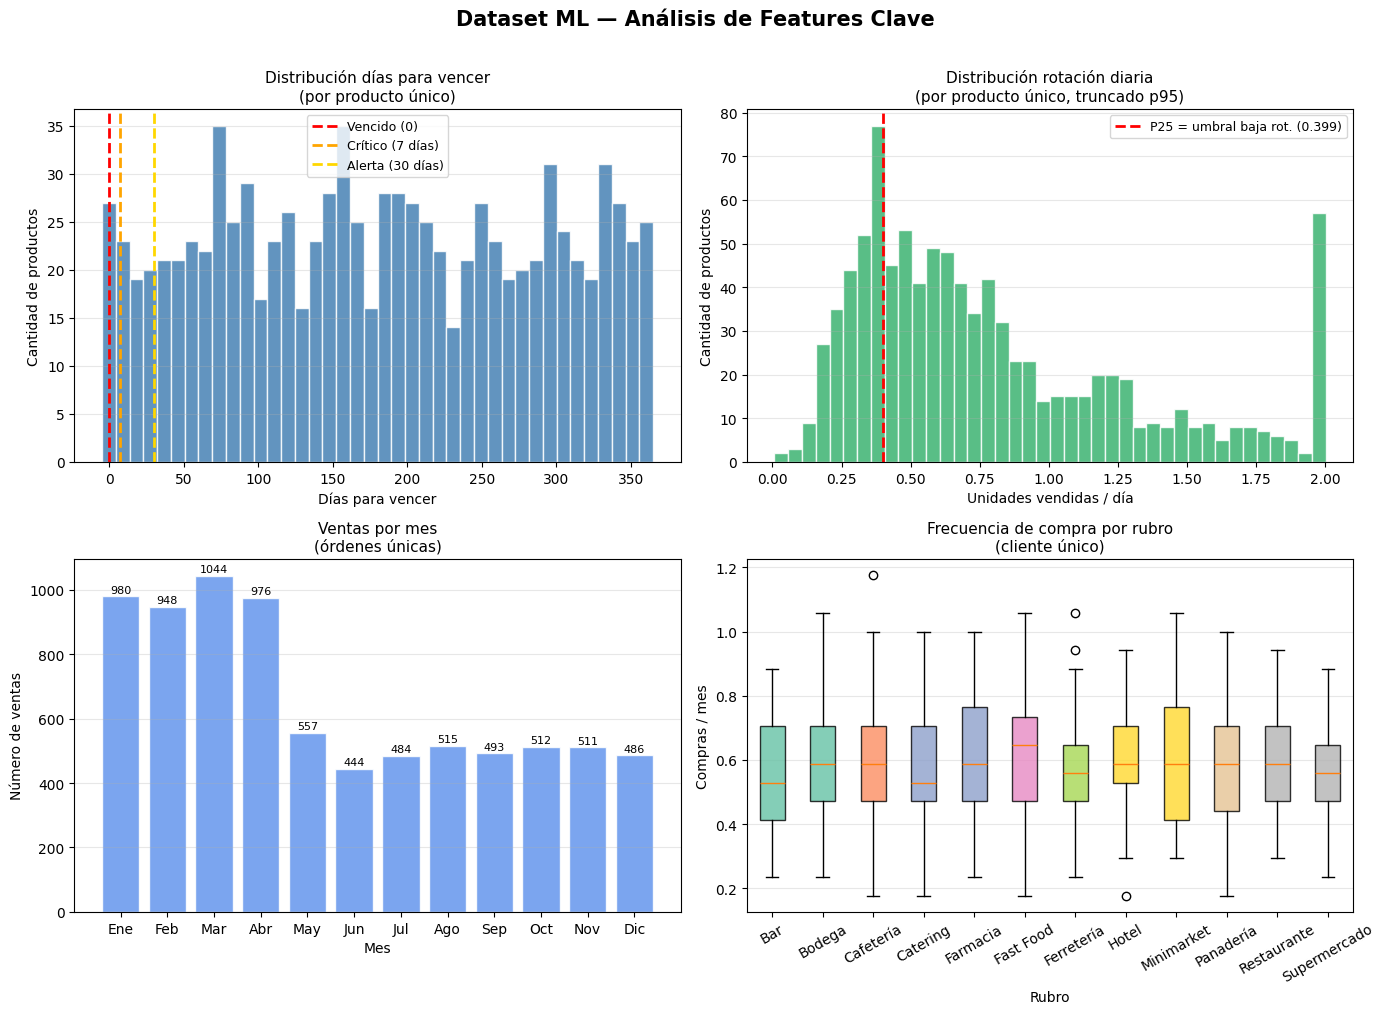

Visualizaciones guardadas en data/processed/01_dataset_visualizaciones.png


In [24]:
# ── Visualizaciones 2×2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset ML — Análisis de Features Clave", fontsize=15, fontweight="bold", y=1.01)

# ── Panel 1: Distribución de dias_para_vencer ─────────────────────────────────
ax1 = axes[0, 0]
# Usamos el nivel de producto para no repetir conteo por líneas de venta
dpv_producto = dataset_final.drop_duplicates("producto_id")["dias_para_vencer"]
ax1.hist(dpv_producto, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax1.axvline(0,  color="red",    linewidth=2, linestyle="--", label="Vencido (0)")
ax1.axvline(7,  color="orange", linewidth=2, linestyle="--", label="Crítico (7 días)")
ax1.axvline(30, color="gold",   linewidth=2, linestyle="--", label="Alerta (30 días)")
ax1.set_title("Distribución días para vencer\n(por producto único)", fontsize=11)
ax1.set_xlabel("Días para vencer")
ax1.set_ylabel("Cantidad de productos")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: Distribución de rotacion_diaria ──────────────────────────────────
ax2 = axes[0, 1]
rot_producto = dataset_final.drop_duplicates("producto_id")["rotacion_diaria"]
# Usamos percentil 95 como límite para no distorsionar por outliers
p95_rot = rot_producto.quantile(0.95)
rot_capped = rot_producto.clip(upper=p95_rot)
ax2.hist(rot_capped, bins=40, color="mediumseagreen", edgecolor="white", alpha=0.85)
p25_rot = rot_producto.quantile(0.25)
ax2.axvline(p25_rot, color="red", linewidth=2, linestyle="--",
            label=f"P25 = umbral baja rot. ({p25_rot:.3f})")
ax2.set_title("Distribución rotación diaria\n(por producto único, truncado p95)", fontsize=11)
ax2.set_xlabel("Unidades vendidas / día")
ax2.set_ylabel("Cantidad de productos")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# ── Panel 3: Ventas por mes ────────────────────────────────────────────────────
ax3 = axes[1, 0]
# Contar ventas únicas por mes (no líneas de detalle)
ventas_por_mes = (
    dataset_final.drop_duplicates("venta_id")
    .groupby("mes")["venta_id"]
    .count()
)
meses_names = ["Ene","Feb","Mar","Abr","May","Jun",
               "Jul","Ago","Sep","Oct","Nov","Dic"]
bars = ax3.bar(
    ventas_por_mes.index,
    ventas_por_mes.values,
    color="cornflowerblue", edgecolor="white", alpha=0.85
)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(meses_names)
ax3.set_title("Ventas por mes\n(órdenes únicas)", fontsize=11)
ax3.set_xlabel("Mes")
ax3.set_ylabel("Número de ventas")
ax3.grid(axis="y", alpha=0.3)
# Anotar valores
for bar, val in zip(bars, ventas_por_mes.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", va="bottom", fontsize=8)

# ── Panel 4: frecuencia_compra por rubro ──────────────────────────────────────
ax4 = axes[1, 1]
# Dataset de clientes únicos para no sesgar boxplot por número de líneas
clientes_feat = (
    dataset_final
    .drop_duplicates("cliente_id")[["cliente_id", "rubro_cliente", "frecuencia_compra"]]
)
rubros = sorted(clientes_feat["rubro_cliente"].unique())
data_boxplot = [clientes_feat[clientes_feat["rubro_cliente"] == r]["frecuencia_compra"].values
                for r in rubros]
bp = ax4.boxplot(data_boxplot, labels=rubros, patch_artist=True, notch=False)
colors_box = plt.cm.Set2(np.linspace(0, 1, len(rubros)))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax4.set_title("Frecuencia de compra por rubro\n(cliente único)", fontsize=11)
ax4.set_xlabel("Rubro")
ax4.set_ylabel("Compras / mes")
ax4.tick_params(axis="x", rotation=30)
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_OUT / "01_dataset_visualizaciones.png", dpi=120, bbox_inches="tight")
plt.show()
print("Visualizaciones guardadas en data/processed/01_dataset_visualizaciones.png")

## 📋 Resumen Final — Las 28 Columnas del Dataset

| # | Columna | Tipo | Fuente | Propósito en el modelo híbrido |
|---|---|---|---|---|
| 1 | `venta_id` | str | ventas | Identificador de transacción; construye la matriz usuario–ítem |
| 2 | `cliente_id` | str | clientes | ID de usuario para filtrado colaborativo |
| 3 | `producto_id` | str | productos | ID de ítem para filtrado colaborativo y basado en contenido |
| 4 | `rubro_cliente` | str | clientes | Feature categórica para segmentación (embedding) |
| 5 | `subrubro_1` | str | clientes | Feature categórica de especialidad (embedding) |
| 6 | `subrubro_2` | str | clientes | Feature categórica de formato de servicio (embedding) |
| 7 | `sede_cliente` | str | clientes | Clave geográfica para filtros de disponibilidad |
| 8 | `categoria_producto` | str | productos | Feature categórica de ítem (embedding); similar a genre en movies |
| 9 | `precio_unitario` | float | productos | Feature numérica; sensibilidad al precio por segmento |
| 10 | `COSTO_UNITARIO` | float | productos | Permite calcular margen; relevante para reglas de negocio |
| 11 | `stock` | int | productos | Feature de disponibilidad; productos sin stock no se recomiendan |
| 12 | `dias_en_stock` | int | productos | Señal de antigüedad del lote; correlaciona con urgencia de venta |
| 13 | `sede` | str | productos | Sede de origen del stock; para matching con sede_cliente |
| 14 | `fecha_ingreso_catalogo` | date | productos | Antigüedad del producto en el portafolio |
| 15 | `fecha_min_caducidad` | date | productos | Base para calcular dias_para_vencer en tiempo real |
| 16 | `dias_para_vencer` | int | calculado | **Feature de urgencia:** booster para productos próximos a vencer |
| 17 | `fecha_venta` | date | ventas | Base para features temporales y análisis de cohortes |
| 18 | `monto_total` | float | ventas | Contexto de la transacción; tamaño del pedido |
| 19 | `cantidad_producto` | int | detalle_venta | Señal de preferencia implícita (más unidades = mayor preferencia) |
| 20 | `subtotal` | float | detalle_venta | Valor monetario de la interacción usuario–ítem |
| 21 | `mes` | int | calculado | Feature de estacionalidad mensual |
| 22 | `semana_anio` | int | calculado | Feature de estacionalidad semanal (más fino que mes) |
| 23 | `es_feriado` | int 0/1 | calculado | Contexto de feriado; modifica patrones de compra |
| 24 | `frecuencia_compra` | float | calculado | Feature de lealtad; clientes frecuentes reciben recomendaciones más personalizadas |
| 25 | `ticket_promedio` | float | calculado | Feature de capacidad adquisitiva; segmenta recomendaciones por rango de precio |
| 26 | `descuento_aplicado` | float | calculado | Feature de sensibilidad al precio; detecta clientes que responden a promociones |
| 27 | `rotacion_diaria` | float | calculado | Velocidad de venta del producto; informa al ranker sobre demanda histórica |
| 28 | `baja_rotacion` | int 0/1 | calculado | **Flag de liquidación:** el componente de reglas de negocio impulsa estos ítems |

---

### Próximos pasos

- **Notebook 02** — Filtrado Colaborativo: matrix factorization sobre la interacción `(cliente_id, producto_id)` usando `cantidad_producto` como feedback implícito.
- **Notebook 03** — Basado en Contenido: encoders para features categóricas, normalización de features numéricas, similitud coseno.
- **Notebook 04** — Reglas de Negocio: boosters de caducidad y rotación, filtros de disponibilidad por sede.
- **Notebook 05** — Modelo Híbrido: combinación ponderada de los tres componentes con optimización de hiperparámetros.